# Machine Learning Modeling

This notebook applies machine learning methods to predict video game success, measured by positive review ratio.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("steam_cleaned.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (27075, 22)
                        name release_date  english         developer  \
0             Counter-Strike   2000-11-01        1             Valve   
1      Team Fortress Classic   1999-04-01        1             Valve   
2              Day of Defeat   2003-05-01        1             Valve   
3         Deathmatch Classic   2001-06-01        1             Valve   
4  Half-Life: Opposing Force   1999-11-01        1  Gearbox Software   

  publisher          platforms  required_age  \
0     Valve  windows;mac;linux             0   
1     Valve  windows;mac;linux             0   
2     Valve  windows;mac;linux             0   
3     Valve  windows;mac;linux             0   
4     Valve  windows;mac;linux             0   

                                          categories  genres  \
0  Multi-player;Online Multi-Player;Local Multi-P...  Action   
1  Multi-player;Online Multi-Player;Local Multi-P...  Action   
2              Multi-player;Valve Anti-Cheat enabled  Action   
3  

In [2]:
features = [
    "price",
    "average_playtime",
    "release_year",
    "game_age",
    "is_free"
]

target = "positive_ratio"

data = df[features + [target]].dropna()

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (27075, 5)
y shape: (27075,)
   price  average_playtime  release_year  game_age  is_free
0   7.19             17612          2000        26        0
1   3.99               277          1999        27        0
2   3.99               187          2003        23        0
3   3.99               258          2001        25        0
4   3.99               624          1999        27        0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (21660, 5)
Test shape: (5415, 5)


## Linear Regression

This model is used as a baseline regression model.

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R^2:", r2_lr)

Linear Regression Results
MAE: 0.1849671019759771
RMSE: 0.23354322979818593
R^2: -0.003047067796418279


## Random Forest Regressor

This model is used as a more flexible nonlinear regression method.

In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R^2:", r2_rf)

Random Forest Results
MAE: 0.1789895341514048
RMSE: 0.22833077330344462
R^2: 0.041227334836136276


In [7]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  0.184967  0.233543 -0.003047
1      Random Forest  0.178990  0.228331  0.041227


## Feature Importance

The following plot shows which features contribute most to the Random Forest model.

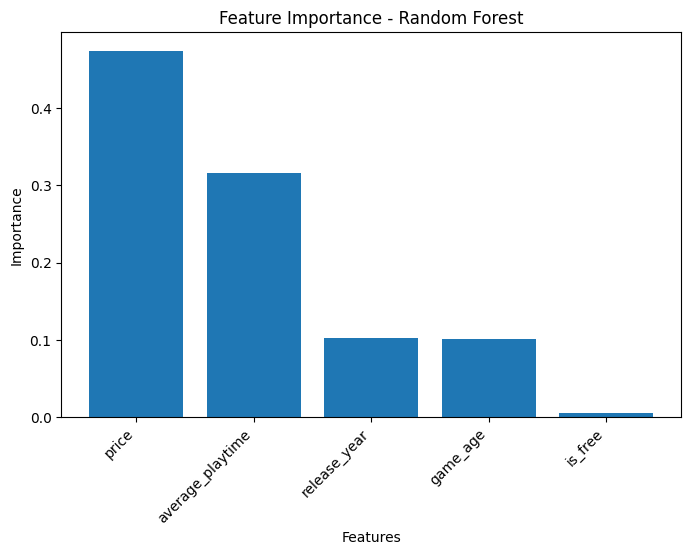

In [8]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importances.index, importances.values)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

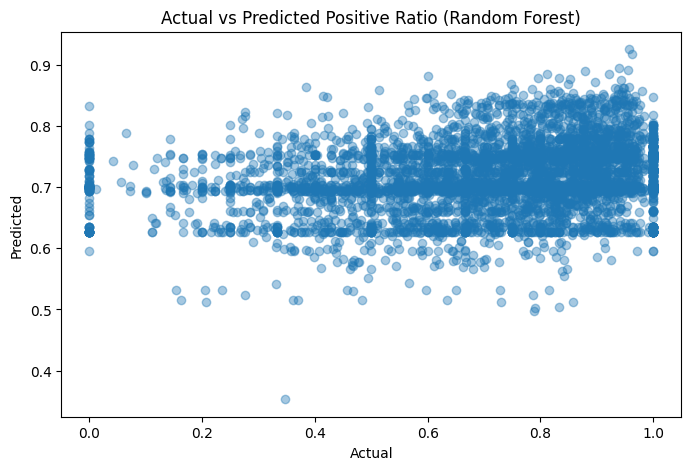

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.title("Actual vs Predicted Positive Ratio (Random Forest)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Conclusion

This notebook applied two machine learning methods to predict video game success, measured by positive review ratio. Linear Regression was used as a baseline model, while Random Forest provided a more flexible alternative. The comparison shows which approach performs better using the selected game-related features.